In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath("../sage")) # go back to root folder to access sage folder
from sage_base import Sage_Explainer

In [4]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

In [5]:
target = diabetes.target
model = LinearRegression()
model.fit(df, target)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
explainer = Sage_Explainer(model.predict)
explainer.fit(df)

In [7]:
instance = df.iloc[0].to_dict()
sensitivities = explainer.explain(instance)
print("sensitivities from explainer")
for feature, val in sensitivities.items():
    print(f"{feature:8}: {val:>10.4f}")

sensitivities from explainer
age     :   -10.0099
sex     :  -239.8156
bmi     :   519.8459
bp      :   324.3846
s1      :  -792.1756
s2      :   476.7390
s3      :   101.0433
s4      :   177.0632
s5      :   751.2737
s6      :    67.6267


In [8]:
print("actual linear model coefficients")
for feature, coef in zip(df.columns, model.coef_):
    print(f"{feature:8}: {coef:>10.4f}")

actual linear model coefficients
age     :   -10.0099
sex     :  -239.8156
bmi     :   519.8459
bp      :   324.3846
s1      :  -792.1756
s2      :   476.7390
s3      :   101.0433
s4      :   177.0632
s5      :   751.2737
s6      :    67.6267


In [9]:
# sage sensitivity values align with linear model coefficients, showing it found correct slopes

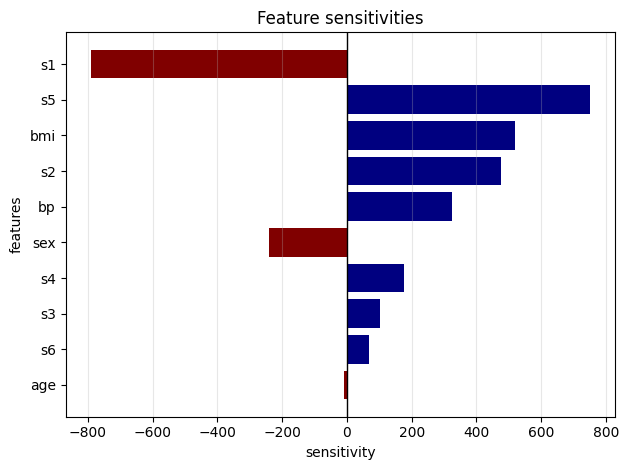

In [10]:
explainer.graph() # wow awesome graph